In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
df = pd.read_parquet("data/downstream2025.parquet")
_exp = "new_factors"
PREFIX = f"model/{_exp}/samples"

In [32]:
gics_map = {
    10: 'Energy',
    15: 'Materials',
    20: 'Industrials',
    25: 'Consumer Discretionary',
    30: 'Consumer Staples',
    35: 'Health Care',
    40: 'Financials',
    45: 'Information Technology',
    50: 'Communication Services',
    55: 'Utilities',
    60: 'Real Estate',
}

df['gics_name'] = df['gics'].astype(int).map(gics_map)

In [33]:
# register any number of scenarios here; colors / subplot grids adapt automatically
SAMPLES_DIR = PREFIX
scenarios = ['momentum_up_30', 'value_up_30', 'value_down_30', 'momentum_down_30']

def make_colors(n, base=('#B50063', '#2ca02c', '#ff7f0e', '#9467bd')):
    colors = list(base)
    cmap = plt.get_cmap('tab20')
    while len(colors) < n:
        colors.append(cmap(len(colors) % cmap.N))
    return colors[:n]

COLORS = make_colors(len(scenarios))

In [34]:
XLSX = "data/portfolio_weights.xlsx"
portfolios = pd.ExcelFile(XLSX)

ws = {}
for strategy in portfolios.sheet_names:
    sheet = portfolios.parse(strategy)
    for col in ("wpnew", "wb"):
        w_ = (sheet[["csecid", col]].rename(columns={col: "w"})
              .dropna(subset=["w"]))
        w_ = w_[w_["w"] != 0]
        ws[f"{strategy} {col}"] = w_

In [35]:
def get_w(df: pd.DataFrame, date) -> pd.DataFrame:
    """baseline strategy: mcap weights ['csecid', 'w'] for one date"""
    day = df[df['date'] == date].dropna(subset=['mcap'])
    return pd.DataFrame({'csecid': day['csecid'], 'w': day['mcap'] / day['mcap'].sum()})

def _day_weights(day: pd.DataFrame, w: pd.DataFrame) -> np.ndarray:
    """Look up each of day's stocks in w (missing -> 0), renormalize to sum 1."""
    wd = day['csecid'].map(w.set_index('csecid')['w']).fillna(0).to_numpy()
    assert wd.sum() > 0
    return wd / wd.sum()

def _scenario_matrix(df_stress: pd.DataFrame) -> pd.DataFrame:
    """Reshape the stacked sample panel into one row per scenario, one column
    per stock: the k-th occurrence of each csecid belongs to scenario k."""
    scn = df_stress.groupby('csecid').cumcount()
    R = df_stress.assign(scn=scn).pivot(index='scn', columns='csecid', values='returns')
    assert not R.isna().any().any(), "some scenario is missing some stock"
    return R

def get_real_pv(df: pd.DataFrame, w: pd.DataFrame = None) -> pd.DataFrame:
    """Daily PV from each day's realized returns (no scenario sampling)."""
    df = df.dropna(subset=['mcap'])
    out = {date: _day_weights(day, w if w is not None else get_w(df, date)) @ day['returns'].to_numpy()
           for date, day in df.groupby('date')}
    return pd.Series(out, name='pv').rename_axis('date').reset_index()

def get_stress_pv(df: pd.DataFrame, df_stress: pd.DataFrame, w: pd.DataFrame = None,
                  seed: int | None = None) -> pd.DataFrame:
    """Portfolio PV per date. Each date draws ONE scenario — a full cross-section,
    so co-movement between stocks within the scenario is preserved. Scenarios are
    already monthly, so the drawn returns are used directly (no compounding)."""
    rng = np.random.default_rng(seed)
    df  = df.dropna(subset=['mcap'])
    R   = _scenario_matrix(df_stress)          # (n_scenarios, n_stocks)

    out = {}
    for date, day in df.groupby('date'):
        wv  = _day_weights(day, w if w is not None else get_w(df, date))
        ret = R.iloc[rng.integers(len(R))][day['csecid']].to_numpy()   # one joint cross-section
        out[date] = wv @ ret
    return pd.Series(out, name='pv').rename_axis('date').reset_index()

def get_sector_pv(df, df_stress, w: pd.DataFrame = None, seed=None):
    """Same draw as get_stress_pv, but PV split into per-sector contributions."""
    rng = np.random.default_rng(seed)
    df  = df.dropna(subset=['mcap'])
    R   = _scenario_matrix(df_stress)

    rows = []
    for date, day in df.groupby('date'):
        wv  = _day_weights(day, w if w is not None else get_w(df, date))
        ret = R.iloc[rng.integers(len(R))][day['csecid']].to_numpy()
        contrib = pd.Series(wv * ret).groupby(day['gics_name'].to_numpy()).sum()
        rows += [(date, sector, pv) for sector, pv in contrib.items()]
    return pd.DataFrame(rows, columns=['date', 'gics_name', 'pv'])

In [36]:
# compute stress PV (portfolio + per-sector) for every scenario, plus uncon baseline
# and the same-named gaussian counterpart ({name}_gaussian.parquet).
# weights: same-day mcap via get_w(df, date); pass w=DataFrame(['csecid','w']) for a custom portfolio
uncon_pv = get_stress_pv(df, pd.read_parquet(f"{SAMPLES_DIR}/uncon.parquet"), seed=0)

stress_pvs,   sector_pvs   = {}, {}   # diffusion: name -> pv
stress_pvs_g, sector_pvs_g = {}, {}   # gaussian baseline: name -> pv
for name in scenarios:
    ds = pd.read_parquet(f"{SAMPLES_DIR}/{name}.parquet")
    stress_pvs[name] = get_stress_pv(df, ds, seed=0)
    sector_pvs[name] = get_sector_pv(df, ds, seed=0)

    dg = pd.read_parquet(f"{SAMPLES_DIR}/{name}_gaussian.parquet")
    stress_pvs_g[name] = get_stress_pv(df, dg, seed=0)
    sector_pvs_g[name] = get_sector_pv(df, dg, seed=0)

    print(f"{name:18s} mean PV {stress_pvs[name]['pv'].mean() * 100:+.2f}%"
          f"  (gaussian {stress_pvs_g[name]['pv'].mean() * 100:+.2f}%)")

momentum_up_30     mean PV +4.80%  (gaussian +2.46%)
value_up_30        mean PV -28.12%  (gaussian +3.55%)
value_down_30      mean PV +26.38%  (gaussian -5.30%)
momentum_down_30   mean PV -1.20%  (gaussian +3.32%)


In [37]:
table = {'real 2025': {
    strat: get_real_pv(df, ws[f"{strat} wpnew"])['pv'].mean()
         - get_real_pv(df, ws[f"{strat} wb"])['pv'].mean()
    for strat in portfolios.sheet_names
}}

for label in scenarios + [f"{n}_gaussian" for n in scenarios]:
    ds = pd.read_parquet(f"{SAMPLES_DIR}/{label}.parquet")
    table[label] = {
        strat: get_stress_pv(df, ds, w=ws[f"{strat} wpnew"], seed=0)['pv'].mean()
             - get_stress_pv(df, ds, w=ws[f"{strat} wb"],    seed=0)['pv'].mean()
        for strat in portfolios.sheet_names
    }
    print(label, 'done')

pv_table = (pd.DataFrame(table) * 100).round(2)
pv_table

momentum_up_30 done
value_up_30 done
value_down_30 done
momentum_down_30 done
momentum_up_30_gaussian done
value_up_30_gaussian done
value_down_30_gaussian done
momentum_down_30_gaussian done


,real 2025,momentum_up_30,value_up_30,value_down_30,momentum_down_30,momentum_up_30_gaussian,value_up_30_gaussian,value_down_30_gaussian,momentum_down_30_gaussian
strategy 1,0.01,2.14,2.80,-2.97,-2.01,1.72,2.25,-2.14,-1.65
strategy 2,0.01,-6.06,33.01,-32.74,6.52,-5.76,30.25,-27.36,5.72
strategy 3,0.09,40.05,8.68,-8.59,-37.44,34.35,2.94,-4.88,-33.77


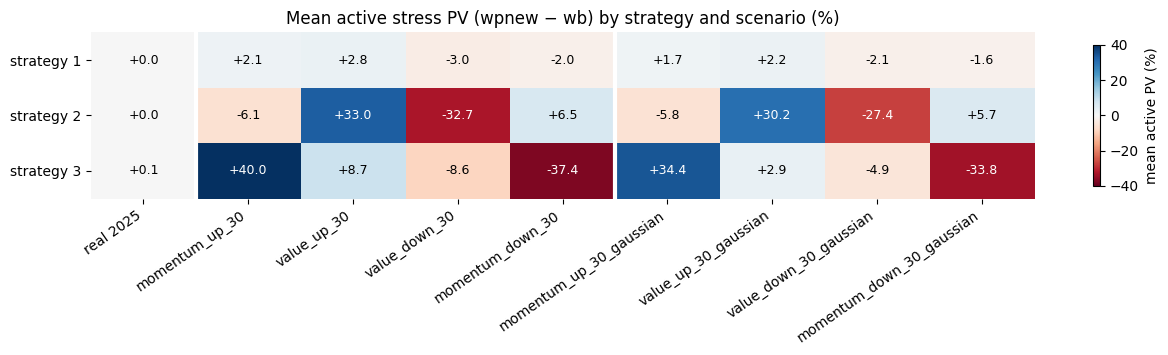

In [38]:

vals = pv_table.to_numpy()
vmax = np.abs(vals).max()

fig, ax = plt.subplots(figsize=(1.1 * pv_table.shape[1] + 3, 0.55 * pv_table.shape[0] + 2))
im = ax.imshow(vals, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(pv_table.shape[1]), pv_table.columns, rotation=35, ha='right')
ax.set_yticks(range(pv_table.shape[0]), pv_table.index)
for spine in ax.spines.values():
    spine.set_visible(False)
for x in (0.5, 0.5 + len(scenarios)):          # separators between the three blocks
    ax.axvline(x, color='white', lw=3)
for i in range(pv_table.shape[0]):
    for j in range(pv_table.shape[1]):
        v = vals[i, j]
        ax.text(j, i, f"{v:+.1f}", ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.6 * vmax else 'black')

fig.colorbar(im, ax=ax, label='mean active PV (%)', shrink=0.85)
ax.set_title('Mean active stress PV (wpnew − wb) by strategy and scenario (%)')
fig.tight_layout()
plt.show()

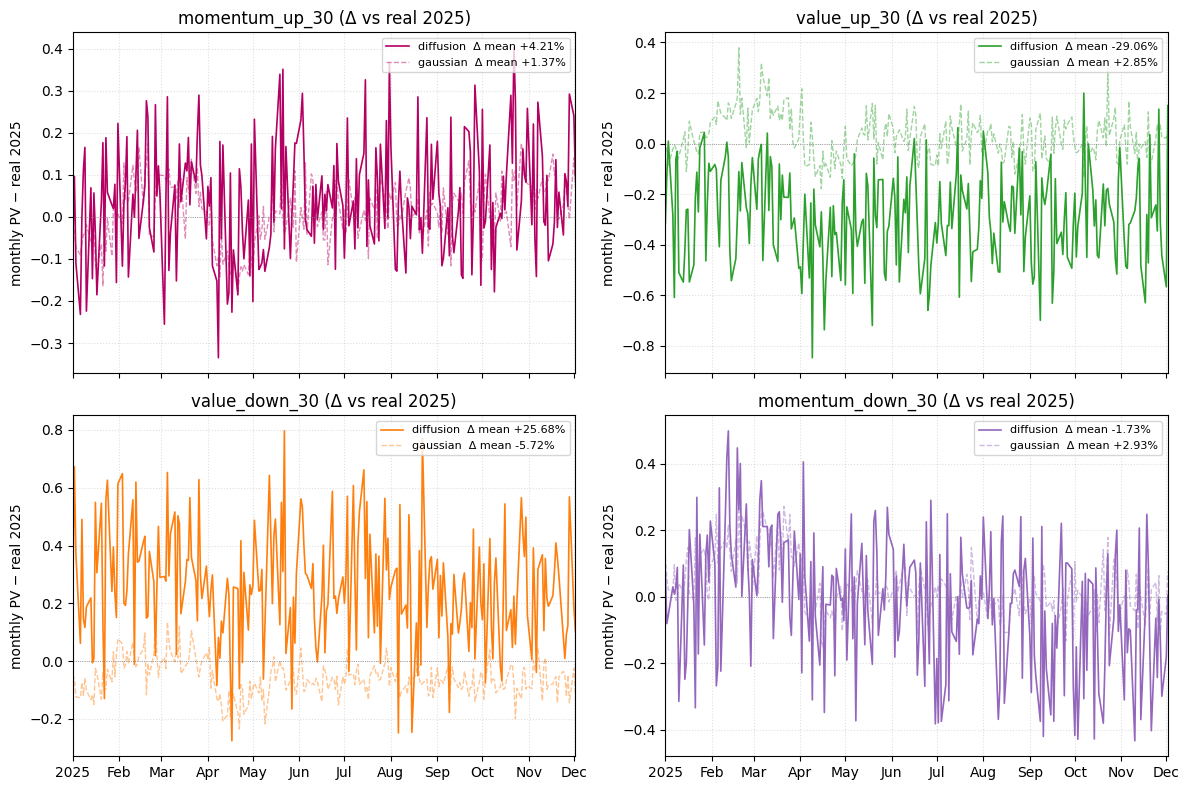

In [41]:
# plot 1: stress portfolio PV delta vs realized 2025 monthly PV, one subplot per scenario
# (independent y-scale), diffusion (solid) vs same-named gaussian baseline (dashed, faint)
import matplotlib.dates as mdates

# realized monthly PV: per stock compound the next 22 trading days, then aggregate
# with same-day mcap weights (mirrors get_stress_pv: weights at t, monthly returns)
_R   = df.dropna(subset=['mcap']).pivot_table(index='date', columns='csecid', values='returns')
_fwd = ((1 + _R.fillna(0)).rolling(22).apply(np.prod, raw=True) - 1).shift(-21)  # window [t, t+21]
_fwd = _fwd.iloc[:-21]                                   # drop tail dates without a full window
real_pv = pd.Series({
    date: _day_weights(day, get_w(df, date)) @ _fwd.loc[date, day['csecid']].fillna(0).to_numpy()
    for date, day in df.dropna(subset=['mcap']).groupby('date') if date in _fwd.index
}, name='pv_real').rename_axis('date').reset_index()

xlim = (real_pv['date'].min(), real_pv['date'].max())   # follow the data range

n = len(scenarios)
ncols = 2
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows),
                         sharex=True, sharey=False)   # each scenario autoscales y
axes = np.atleast_1d(axes).ravel()
for ax, name, color in zip(axes, scenarios, COLORS):
    pv   = stress_pvs[name].merge(real_pv, on='date')
    pv_g = stress_pvs_g[name].merge(real_pv, on='date')
    delta   = pv['pv'].values   - pv['pv_real'].values
    delta_g = pv_g['pv'].values - pv_g['pv_real'].values
    ax.plot(pv['date'], delta, color=color, lw=1.2,
            label=f"diffusion  Δ mean {delta.mean() * 100:+.2f}%")
    ax.plot(pv_g['date'], delta_g, color=color, lw=1.0, ls="--", alpha=0.45,
            label=f"gaussian  Δ mean {delta_g.mean() * 100:+.2f}%")
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(f"{name} (Δ vs real 2025)")
    ax.set_ylabel("monthly PV − real 2025")
    ax.grid(True, ls=":", alpha=0.4)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(*xlim)
    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
for ax in axes[n:]:                # hide unused panels
    ax.set_visible(False)
fig.tight_layout()
plt.show()

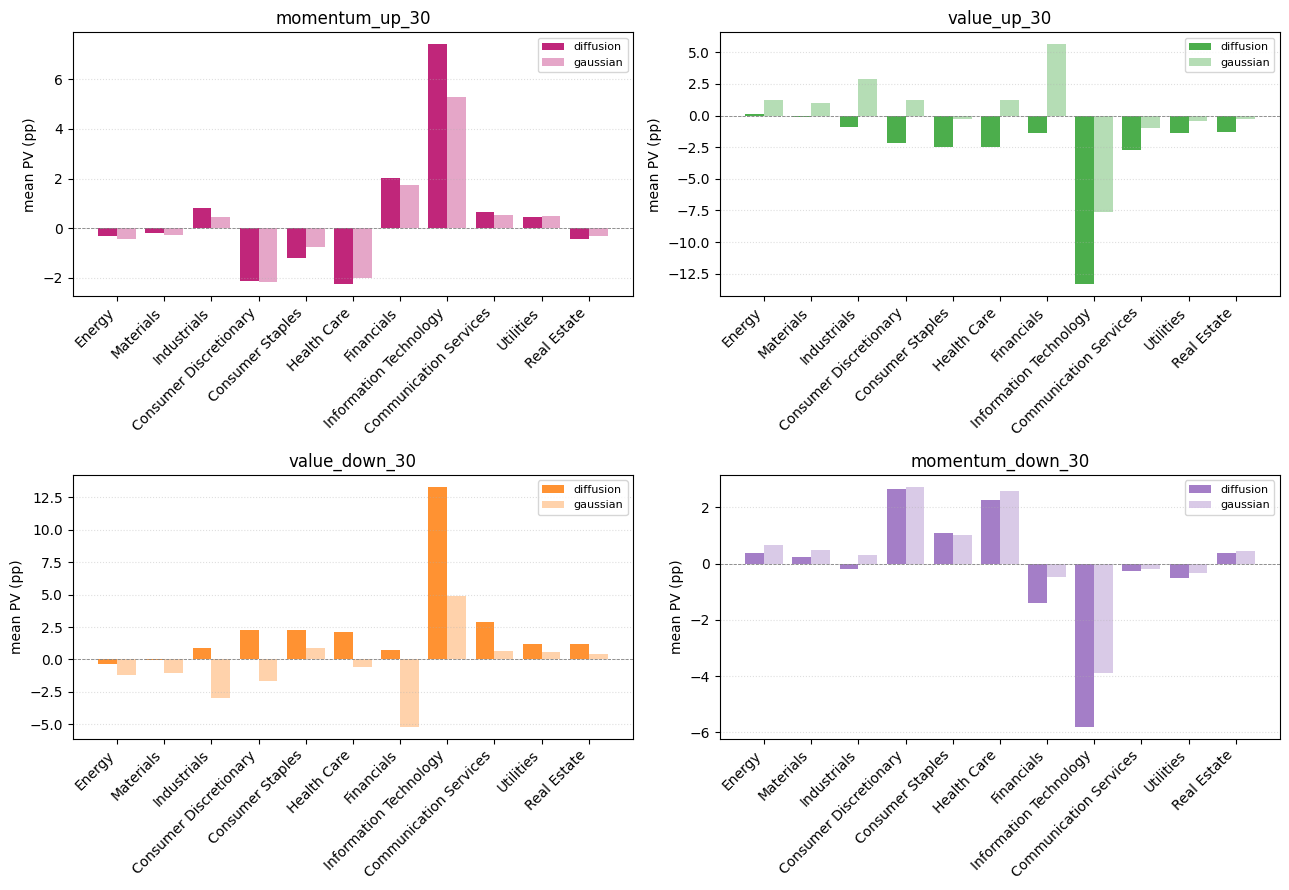

In [40]:
# plot 2: per-sector mean PV, one subplot per scenario (independent y-scale),
# diffusion (solid) vs same-named gaussian baseline (faint), grouped bars
means   = {name: sp.groupby('gics_name')['pv'].mean() for name, sp in sector_pvs.items()}
means_g = {name: sp.groupby('gics_name')['pv'].mean() for name, sp in sector_pvs_g.items()}
present = set().union(*(m.index for m in list(means.values()) + list(means_g.values())))
sectors = [s for s in gics_map.values() if s in present]    # keep GICS order

n = len(scenarios)
ncols = 2
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.5 * nrows),
                         sharex=False, sharey=False)   # each subplot keeps its own x/y axis
axes = np.atleast_1d(axes).ravel()
x = np.arange(len(sectors))
bw = 0.4                                                # bar width for each variant
for ax, name, color in zip(axes, scenarios, COLORS):
    vals   = [means[name].get(s, np.nan)   * 100 for s in sectors]
    vals_g = [means_g[name].get(s, np.nan) * 100 for s in sectors]
    ax.bar(x - bw / 2, vals,   width=bw, color=color, alpha=0.85, label="diffusion")
    ax.bar(x + bw / 2, vals_g, width=bw, color=color, alpha=0.35, label="gaussian")
    ax.set_title(name)
    ax.set_ylabel("mean PV (pp)")
    ax.axhline(0, color="grey", lw=0.6, ls="--")
    ax.grid(True, ls=":", alpha=0.4, axis='y')
    ax.set_xticks(x)
    ax.set_xticklabels(sectors, rotation=45, ha='right')
    ax.legend(fontsize=8)
for ax in axes[n:]:                # hide unused panels
    ax.set_visible(False)
fig.tight_layout()
plt.show()